# Unsupervised baseline: PCA → k-means (+ hyperparameter experiments)

**Data:** `food_nutrient_conc.csv` in the parent folder (`StatLearning_FinalProject/`), one row per food.

**Features:** By default `load_feature_matrix` uses **micronutrient-only** columns (`nutrient_definitions.py`, same rules as `R/nutrient_definitions.R`).

**CLI:** from `unsupervised_learning/` run `python unsupervised_pca_kmeans.py` (add `--all-numeric-nutrients` for every numeric column).

**Outputs:** figures in **`plots/unsupervised/`**; tables in **`results/`** including grid CSVs and **`unsupervised_k_vs_wweia_nmi_ari.csv`** after you run the export cell.

**Notebook:** imports resolve whether your Jupyter working directory is `StatLearning_FinalProject` or `unsupervised_learning`.

**Later sections:** WWEIA label summary (`supervised_table.csv`), wider **K** grid (4 to 50), silhouette heatmap, **NMI/ARI vs WWEIA** (diagnostic only), no-PCA ablation, stability, PC loadings, CSV exports.


In [1]:
%matplotlib inline

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    adjusted_rand_score,
    calinski_harabasz_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Resolve sibling folder whether Jupyter cwd is repo root or unsupervised_learning/
_cwd = Path.cwd().resolve()
for _p in (_cwd, _cwd / "unsupervised_learning"):
    if (_p / "unsupervised_pca_kmeans.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break
else:
    raise ImportError(
        "Place cwd at StatLearning_FinalProject or unsupervised_learning "
        "so unsupervised_pca_kmeans.py can be imported."
    )

import importlib

import unsupervised_pca_kmeans as _upk

importlib.reload(_upk)

from unsupervised_pca_kmeans import (
    DEFAULT_K_CLUSTERS,
    DEFAULT_N_COMPONENTS_KMEANS,
    PROJECT_ROOT,
    SCREE_PLOT_COMPONENTS,
    fit_pca_kmeans,
    load_feature_matrix,
)

PLOTS_DIR_UNSUPERVISED = getattr(
    _upk, "PLOTS_DIR_UNSUPERVISED", PROJECT_ROOT / "plots" / "unsupervised"
)
RESULTS_DIR = getattr(_upk, "RESULTS_DIR", PROJECT_ROOT / "results")

In [2]:
DATA_PATH = PROJECT_ROOT / "food_nutrient_conc.csv"

PLOTS_DIR_UNSUPERVISED.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

K = DEFAULT_K_CLUSTERS
PC_FOR_KMEANS = DEFAULT_N_COMPONENTS_KMEANS
RANDOM_SEED = 42

assert DATA_PATH.is_file(), f"Missing data file: {DATA_PATH}"

In [43]:
X_raw, food_names = load_feature_matrix(DATA_PATH)
print(f"Foods: {len(X_raw):,} | Nutrient features: {X_raw.shape[1]}")
X_raw

Foods: 5,431 | Nutrient features: 34


,"Calcium, Ca",Retinol,Lycopene,"Carotene, beta",Thiamin,"Vitamin B-12, added","Phosphorus, P",Folic acid,Vitamin E (alpha-tocopherol),Vitamin B-6,...,Vitamin D (D2 + D3),"Potassium, K","Iron, Fe","Selenium, Se","Vitamin A, RAE","Vitamin E, added","Folate, total","Sodium, Na","Vitamin C, total ascorbic acid",Theobromine
0,125,57,0,4,0.057,0.0,103,0,0.03,0.061,...,1.1,156,0.00,1.9,58,0.0,1,39,0.1,0
1,123,31,0,7,0.056,0.0,101,0,0.05,0.061,...,1.1,150,0.00,1.9,32,0.0,0,38,0.0,0
2,126,83,0,3,0.059,0.0,103,0,0.03,0.061,...,1.1,159,0.00,1.8,83,0.0,2,39,0.2,0
3,126,58,0,1,0.057,0.0,103,0,0.02,0.060,...,1.1,159,0.00,2.1,58,0.0,2,39,0.0,0
4,132,64,0,2,0.056,0.0,107,0,0.00,0.058,...,1.1,167,0.00,2.0,64,0.0,2,41,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5426,21,0,458,994,0.064,0.0,46,0,0.24,0.178,...,0.0,311,0.56,0.4,98,0.0,27,20,17.1,0
5427,17,0,764,433,0.063,0.0,47,0,0.35,0.132,...,0.0,331,0.45,0.2,38,0.0,26,15,21.0,0
5428,21,0,1088,2588,0.066,0.0,48,0,0.38,0.136,...,0.0,325,0.46,0.2,259,0.0,25,34,14.0,0
5429,18,4,7237,194,0.028,0.0,33,0,1.90,0.104,...,0.1,190,0.43,4.5,21,0.0,8,845,2.5,0


### Supervised table (WWEIA categories) — exploratory context only

`supervised_table.csv` has **coarse menu-level labels** (`wweia_food_category_description`), not “true” micronutrient clusters. There are **~171** categories for **~5.4k** foods: many small classes, and labels are **granular** (e.g. several separate “Milk, …” types).  

This is **not** used when fitting k-means (no leakage into `X_raw`). Below we only **summarize** the label distribution. Later, after the PC grid is fit, we **compare** k-means partitions to WWEIA for several **K** using **NMI** and **ARI** *only as diagnostics* — high overlap is not expected because the tasks differ.


In [4]:
SUP_PATH = PROJECT_ROOT / "supervised_table.csv"
assert SUP_PATH.is_file(), f"Missing {SUP_PATH}"
sup_tbl = pd.read_csv(SUP_PATH)
label_col = "wweia_food_category_description"
if label_col not in sup_tbl.columns:
    raise KeyError(f"Expected column {label_col!r} in supervised_table.csv")

y_wweia = sup_tbl.set_index("Food_Name")[label_col]
vc = y_wweia.value_counts()
print(f"Supervised table rows: {len(sup_tbl):,}")
print(f"Distinct {label_col}: {vc.size}")
summary = pd.DataFrame(
    {
        "metric": [
            "min class size",
            "median class size",
            "90th %-ile class size",
            "max class size",
            "classes with ≤10 foods",
            "singleton classes (count)",
        ],
        "value": [
            int(vc.min()),
            float(vc.median()),
            float(vc.quantile(0.9)),
            int(vc.max()),
            int((vc <= 10).sum()),
            int((vc == 1).sum()),
        ],
    }
)
display(summary)

milk_like = sorted({c for c in y_wweia.unique() if isinstance(c, str) and "milk" in c.lower()})
print(f"\nExample fine-grained categories containing 'milk' ({len(milk_like)} total):")
for c in milk_like[:15]:
    print(f"  - {c}")
if len(milk_like) > 15:
    print("  ...")


Supervised table rows: 5,431
Distinct wweia_food_category_description: 171


,metric,value
0,min class size,1.0
1,median class size,18.0
2,90th %-ile class size,70.0
3,max class size,233.0
4,classes with ≤10 foods,42.0
5,singleton classes (count),3.0



Example fine-grained categories containing 'milk' (10 total):
  - Flavored milk, lowfat
  - Flavored milk, nonfat
  - Flavored milk, reduced fat
  - Flavored milk, whole
  - Milk shakes and other dairy drinks
  - Milk, lowfat
  - Milk, nonfat
  - Milk, reduced fat
  - Milk, whole
  - Plant-based milk


In [5]:
result = fit_pca_kmeans(
    X_raw,
    food_names,
    k=K,
    pc_kmeans=PC_FOR_KMEANS,
    seed=RANDOM_SEED,
)

evr = result.pca.explained_variance_ratio_
cum = np.cumsum(evr)
print(f"K-means: K={K}, PCs used for clustering={result.n_pc_kmeans}")
print(f"Inertia: {result.kmeans.inertia_:,.2f} | Silhouette: {result.silhouette:.4f}")
print(
    f"Variance: PC1={evr[0]*100:.2f}% | PC2={evr[1]*100:.2f}% | "
    f"Cumulative (first {result.n_pc_kmeans} PCs)={cum[result.n_pc_kmeans - 1]*100:.2f}%"
)

K-means: K=8, PCs used for clustering=15
Inertia: 86,691.24 | Silhouette: 0.2461
Variance: PC1=21.25% | PC2=9.50% | Cumulative (first 15 PCs)=82.80%


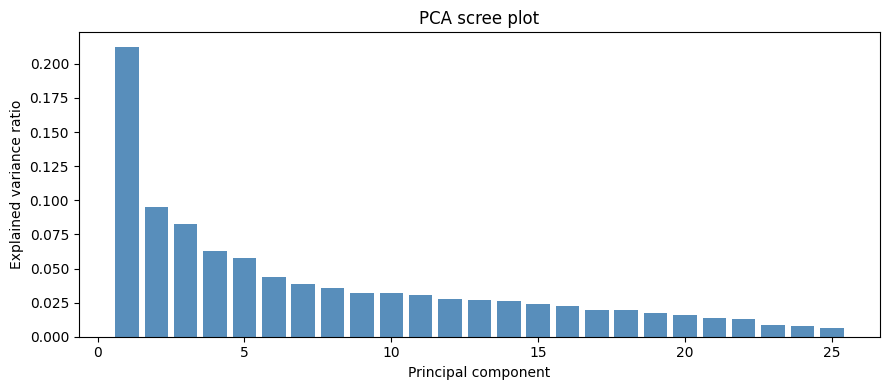

In [6]:
n_scree = min(SCREE_PLOT_COMPONENTS, len(evr))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(np.arange(1, n_scree + 1), evr[:n_scree], color="steelblue", alpha=0.9)
ax.set_xlabel("Principal component")
ax.set_ylabel("Explained variance ratio")
ax.set_title("PCA scree plot")
fig.tight_layout()

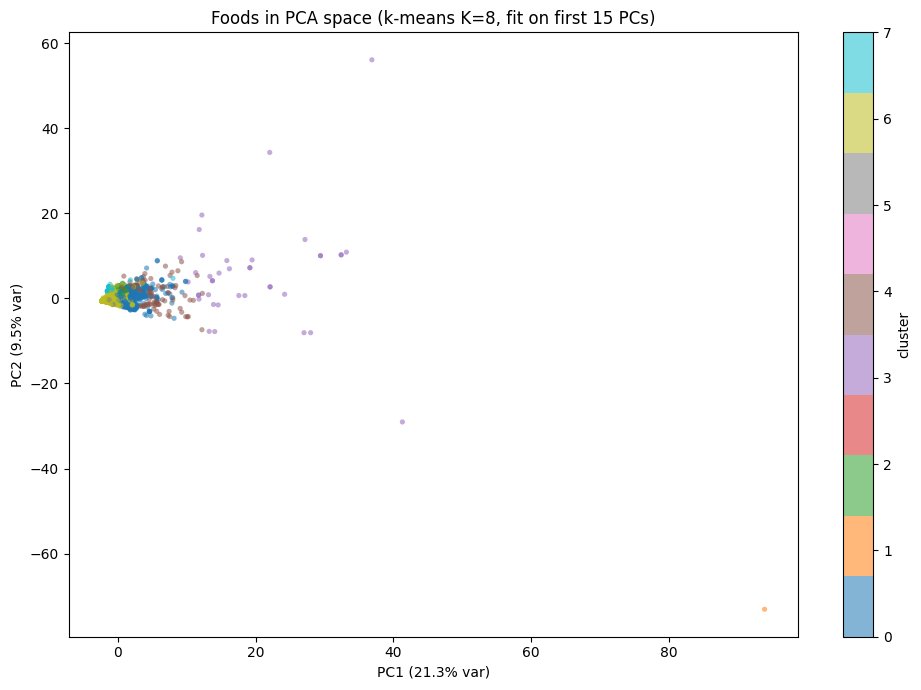

In [7]:
Z = result.Z
fig, ax = plt.subplots(figsize=(10, 7))
sc = ax.scatter(
    Z[:, 0],
    Z[:, 1],
    c=result.cluster_labels,
    cmap="tab10",
    alpha=0.55,
    s=14,
    linewidths=0,
)
ax.set_xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
ax.set_ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
ax.set_title(
    f"Foods in PCA space (k-means K={K}, fit on first {result.n_pc_kmeans} PCs)"
)
plt.colorbar(sc, ax=ax, label="cluster")
fig.tight_layout()

In [8]:
assignments = pd.DataFrame(
    {
        "Food_Name": result.food_names.values,
        "PC1": Z[:, 0],
        "PC2": Z[:, 1],
        "cluster": result.cluster_labels,
    }
)
assignments.groupby("cluster")["Food_Name"].count().rename("n_foods")

cluster
0    1859
1       1
2      71
3      39
4     327
5     221
6    2863
7      50
Name: n_foods, dtype: int64

In [9]:
assignments.sort_values("PC1").tail(8)

,Food_Name,PC1,PC2,cluster
5353,Nutritional powder mix (Slim Fast),29.401091,10.040740,3
5354,"Nutritional powder mix, sugar free (Slim Fast)",29.401091,10.040740,3
5349,"Nutritional powder mix, high protein (Herbalife)",32.403699,10.244992,3
5357,"Nutritional powder mix, high protein, NFS",32.403699,10.244992,3
5355,"Nutritional powder mix, high protein (Slim Fast)",33.163158,10.878487,3
769,"Liver, beef",36.863083,56.099939,3
4621,Yeast,41.292734,-29.037686,3
4622,Yeast extract spread,93.864165,-73.076179,1


## Hyperparameter experiments

**Motivation:** The baseline fixes \(K=8\) clusters and uses \(m=15\) principal components for k-means. We treat both as *tunable*: domain knowledge suggests a rough scale for \(K\); the number of PCs controls how much of the PCA subspace shapes Euclidean distance before clustering.

**Procedure:** Median-impute and scale (same as baseline). Fit **one** full PCA to get scores `Z`. For each pair \((K, m)\), run k-means on `Z[:, :m]` and record **silhouette** (primary), **inertia**, and **Calinski–Harabasz** in that same \(m\)-dimensional space.

**Ablation:** k-means on the **same** scaled micronutrient matrix without PCA (\(p\) equals the number of micronutrient columns, e.g. 34) for each \(K\), with silhouette in that \(p\)-dimensional space—what that k-means run optimizes.


In [10]:
feat_names = X_raw.columns.to_list()
preprocess_grid = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
    ]
)
X_mat = preprocess_grid.fit_transform(X_raw)
n_samples, p = X_mat.shape
max_pc = int(min(n_samples, p))

pca_grid = PCA(random_state=RANDOM_SEED)
Z_full = pca_grid.fit_transform(X_mat)
evr_grid = pca_grid.explained_variance_ratio_

K_grid = list(range(4, 51, 2))  # try larger K (4..50); silhouette often peaks low — compare to WWEIA diagnostics below
m_candidates = sorted({5, 8, 10, 12, 15, 20, 25, min(30, max_pc)})
m_grid = [m for m in m_candidates if 1 <= m <= max_pc]

rows_grid = []
for m in m_grid:
    Zm = Z_full[:, :m]
    for k in K_grid:
        if k < 2 or k >= len(X_mat):
            continue
        km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
        labels = km.fit_predict(Zm)
        rows_grid.append(
            {
                "K": k,
                "m": m,
                "silhouette": silhouette_score(Zm, labels),
                "inertia": km.inertia_,
                "calinski_harabasz": calinski_harabasz_score(Zm, labels),
            }
        )
grid_df = pd.DataFrame(rows_grid)

rows_raw = []
for k in K_grid:
    if k < 2 or k >= len(X_mat):
        continue
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    labels = km.fit_predict(X_mat)
    rows_raw.append(
        {
            "K": k,
            "silhouette": silhouette_score(X_mat, labels),
            "inertia": km.inertia_,
            "calinski_harabasz": calinski_harabasz_score(X_mat, labels),
        }
    )
no_pca_df = pd.DataFrame(rows_raw)

print(f"PCA path: {len(grid_df)} (K, m) fits | No-PCA path: {len(no_pca_df)} fits")
best_idx = grid_df["silhouette"].idxmax()
print("\nBest (K, m) by silhouette (PCA path):")
print(grid_df.loc[best_idx])


PCA path: 192 (K, m) fits | No-PCA path: 24 fits

Best (K, m) by silhouette (PCA path):
K                        4.000000
m                        5.000000
silhouette               0.854221
inertia              53407.905128
calinski_harabasz     1381.710015
Name: 0, dtype: float64


### k-means vs WWEIA labels (diagnostic only)

Fix **m = `PC_FOR_KMEANS`** (same as baseline) and scan **K** over `K_grid`. For each fit, report **NMI** and **ARI** between k-means cluster IDs and WWEIA categories. These scores need not be high: WWEIA reflects **menu grouping**, clustering uses **micronutrients only**. The plot is to see whether agreement **rises** into a moderate **K** range (e.g. tens of clusters) as you suspected when comparing to ~171 (noisy) labels.


PC space for this comparison: m = 15 (same truncation as baseline default)

K with largest NMI vs WWEIA:
K      48.000000
NMI     0.447427
ARI     0.075913
Name: 22, dtype: float64

K with largest ARI vs WWEIA:
K      50.000000
NMI     0.447389
ARI     0.075983
Name: 23, dtype: float64


,K,NMI,ARI
0,4,0.046426,0.001173
1,6,0.206726,0.017444
2,8,0.251584,0.019091
3,10,0.253709,0.019326
4,12,0.265044,0.019500
5,14,0.269769,0.020379
6,16,0.305220,0.025200
7,18,0.319512,0.027076
8,20,0.352694,0.042823
9,22,0.340661,0.030210


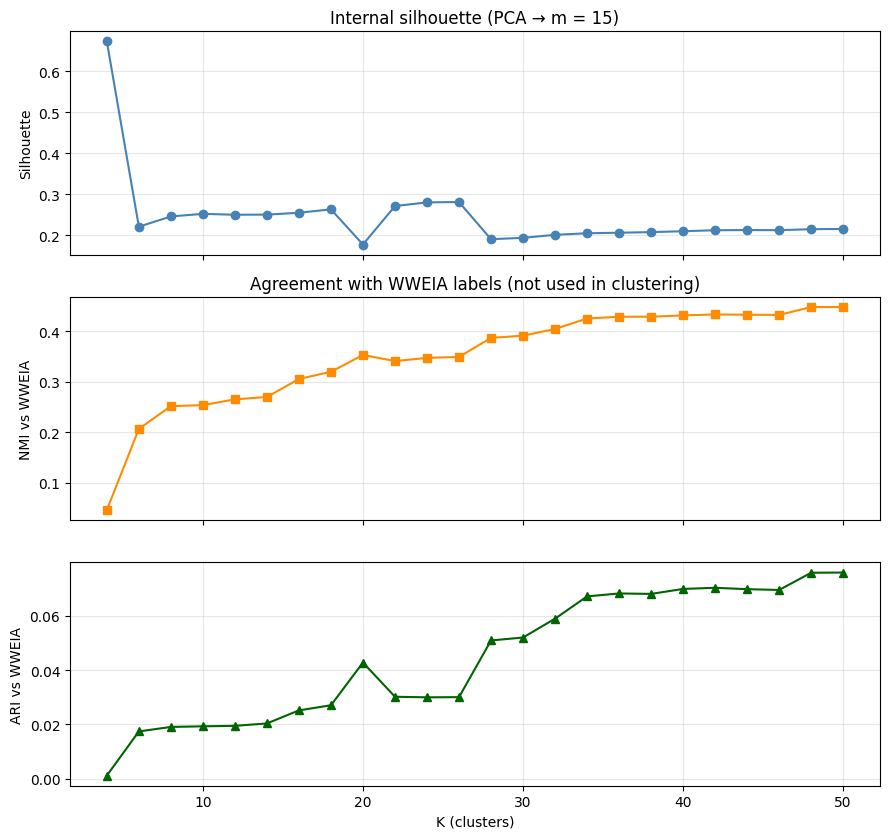

In [11]:
name_to_cat = sup_tbl.set_index("Food_Name")[label_col]
y_true_raw = food_names.map(name_to_cat)
if y_true_raw.isna().any():
    miss = int(y_true_raw.isna().sum())
    raise ValueError(f"{miss} foods missing WWEIA label after Food_Name merge")

y_true_enc = LabelEncoder().fit_transform(y_true_raw.astype(str))

m_ref = int(PC_FOR_KMEANS) if int(PC_FOR_KMEANS) in m_grid else int(m_grid[len(m_grid) // 2])
Zm_ref = Z_full[:, :m_ref]

rows_sup = []
for k in K_grid:
    if k < 2 or k >= len(X_mat):
        continue
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init="auto")
    pred = km.fit_predict(Zm_ref)
    rows_sup.append(
        {
            "K": k,
            "NMI": normalized_mutual_info_score(y_true_enc, pred),
            "ARI": adjusted_rand_score(y_true_enc, pred),
        }
    )
sup_vs_k_df = pd.DataFrame(rows_sup)
print(f"PC space for this comparison: m = {m_ref} (same truncation as baseline default)\n")
print("K with largest NMI vs WWEIA:")
print(sup_vs_k_df.loc[sup_vs_k_df["NMI"].idxmax()])
print("\nK with largest ARI vs WWEIA:")
print(sup_vs_k_df.loc[sup_vs_k_df["ARI"].idxmax()])
display(sup_vs_k_df)

sil_mref = grid_df[grid_df["m"] == m_ref].sort_values("K")

fig, axes = plt.subplots(3, 1, figsize=(9, 8.5), sharex=True)
axes[0].plot(sil_mref["K"], sil_mref["silhouette"], "o-", color="steelblue")
axes[0].set_ylabel("Silhouette")
axes[0].set_title(f"Internal silhouette (PCA → m = {m_ref})")
axes[0].grid(True, alpha=0.3)

axes[1].plot(sup_vs_k_df["K"], sup_vs_k_df["NMI"], "s-", color="darkorange")
axes[1].set_ylabel("NMI vs WWEIA")
axes[1].set_title("Agreement with WWEIA labels (not used in clustering)")
axes[1].grid(True, alpha=0.3)

axes[2].plot(sup_vs_k_df["K"], sup_vs_k_df["ARI"], "^-", color="darkgreen")
axes[2].set_ylabel("ARI vs WWEIA")
axes[2].set_xlabel("K (clusters)")
axes[2].grid(True, alpha=0.3)
plt.tight_layout()


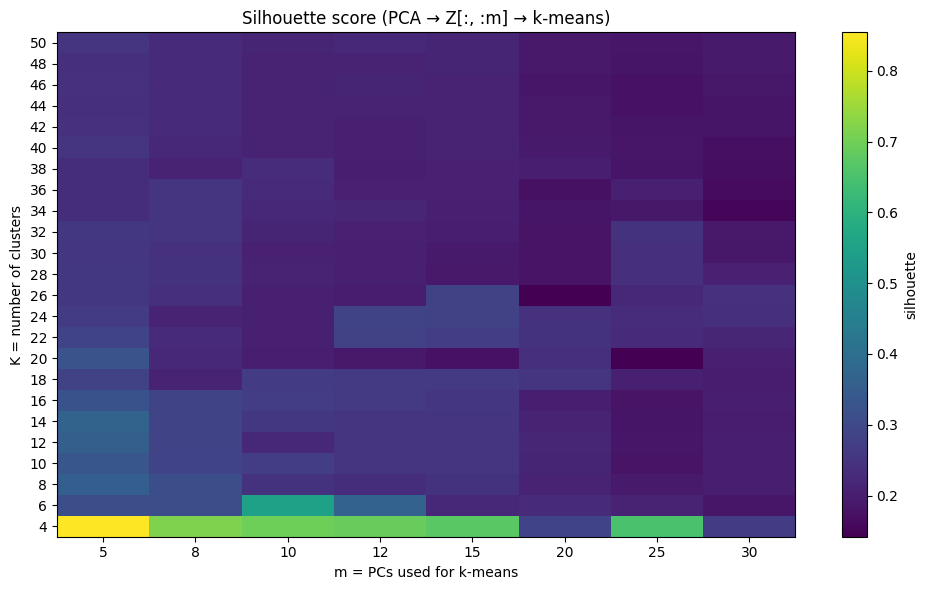

In [12]:
pivot_sil = grid_df.pivot(index="K", columns="m", values="silhouette")
fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(pivot_sil.values, aspect="auto", origin="lower", cmap="viridis")
ax.set_xticks(np.arange(len(pivot_sil.columns)))
ax.set_xticklabels(pivot_sil.columns)
ax.set_yticks(np.arange(len(pivot_sil.index)))
ax.set_yticklabels(pivot_sil.index)
ax.set_xlabel("m = PCs used for k-means")
ax.set_ylabel("K = number of clusters")
ax.set_title("Silhouette score (PCA → Z[:, :m] → k-means)")
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("silhouette")
plt.tight_layout()


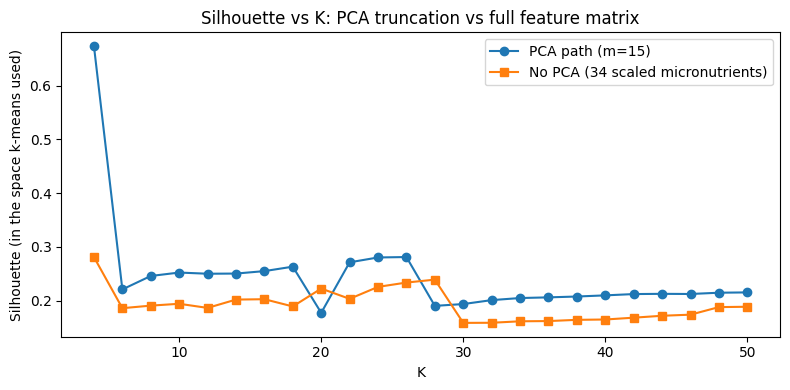

In [13]:
m_line = 15 if 15 in m_grid else m_grid[len(m_grid) // 2]
sub_pca = grid_df[grid_df["m"] == m_line].sort_values("K")
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(sub_pca["K"], sub_pca["silhouette"], marker="o", label=f"PCA path (m={m_line})")
sub_raw = no_pca_df.sort_values("K")
ax.plot(
    sub_raw["K"],
    sub_raw["silhouette"],
    marker="s",
    label=f"No PCA ({p} scaled micronutrients)",
)
ax.set_xlabel("K")
ax.set_ylabel("Silhouette (in the space k-means used)")
ax.set_title("Silhouette vs K: PCA truncation vs full feature matrix")
ax.legend()
plt.tight_layout()


### Stability across random seeds

k-means includes random initialization. Below: **adjusted Rand index (ARI)** between cluster labels for seeds 42, 17, and 99 (1 = identical partitions up to label permutations). We evaluate the **best \((K,m)\)** from the grid by silhouette and the **baseline** \((K, m) = (8, 15)\).


In [14]:
def kmeans_labels(Z_sub: np.ndarray, k: int, seed: int) -> np.ndarray:
    km = KMeans(n_clusters=k, random_state=seed, n_init="auto")
    return km.fit_predict(Z_sub)


best_row = grid_df.loc[grid_df["silhouette"].idxmax()]
pair_candidates = [
    (int(best_row["K"]), int(best_row["m"])),
    (int(K), int(PC_FOR_KMEANS)),
]
seen = set()
pairs_eval = []
for pair in pair_candidates:
    if pair not in seen:
        seen.add(pair)
        pairs_eval.append(pair)

seeds_stable = [42, 17, 99]
stab_rows = []
for k_s, m_s in pairs_eval:
    Zm = Z_full[:, :m_s]
    labs = [kmeans_labels(Zm, k_s, s) for s in seeds_stable]
    stab_rows.append(
        {
            "K": k_s,
            "m": m_s,
            "ARI_42_17": adjusted_rand_score(labs[0], labs[1]),
            "ARI_42_99": adjusted_rand_score(labs[0], labs[2]),
            "ARI_17_99": adjusted_rand_score(labs[1], labs[2]),
        }
    )
stab_df = pd.DataFrame(stab_rows)
display(stab_df)


,K,m,ARI_42_17,ARI_42_99,ARI_17_99
0,4,5,0.024919,0.026343,0.708796
1,8,15,0.748764,0.660434,0.769424


### Interpreting PCs: top nutrient loadings

Each row of `pca.components_` shows how standardized nutrients combine to form a PC (weights in **scaled** feature space). Below: nutrients with largest absolute loading on PC1–PC3.


In [15]:
def top_loadings(pca, feature_names, pc_idx, topn=8):
    loadings = pca.components_[pc_idx]
    order = np.argsort(np.abs(loadings))[::-1][:topn]
    return pd.DataFrame(
        {"nutrient": [feature_names[i] for i in order], "loading": loadings[order]}
    )


for j in range(3):
    print(f"\n--- PC{j + 1} (explained var ratio = {evr_grid[j] * 100:.2f}%) ---")
    display(top_loadings(pca_grid, feat_names, j))



--- PC1 (explained var ratio = 21.25%) ---


,nutrient,loading
0,Niacin,0.300989
1,"Folate, DFE",0.299015
2,Riboflavin,0.298380
3,"Folate, total",0.295268
4,Thiamin,0.276119
5,Folic acid,0.270725
6,Vitamin B-6,0.221454
7,"Magnesium, Mg",0.209703



--- PC2 (explained var ratio = 9.50%) ---


,nutrient,loading
0,"Vitamin A, RAE",0.348374
1,Retinol,0.337906
2,Vitamin B-12,0.323798
3,"Copper, Cu",0.302521
4,Thiamin,-0.295848
5,"Folate, DFE",-0.277744
6,Folic acid,-0.269998
7,"Folate, total",-0.264794



--- PC3 (explained var ratio = 8.23%) ---


,nutrient,loading
0,"Carotene, beta",0.480472
1,Lutein + zeaxanthin,0.455349
2,Vitamin K (phylloquinone),0.455027
3,"Carotene, alpha",0.251436
4,"Vitamin A, RAE",0.233777
5,"Vitamin C, total ascorbic acid",0.216364
6,"Phosphorus, P",-0.189629
7,"Folate, food",0.171882


In [16]:
grid_csv = RESULTS_DIR / "unsupervised_grid_k_m_metrics.csv"
no_pca_csv = RESULTS_DIR / "unsupervised_grid_k_no_pca_metrics.csv"
grid_df.to_csv(grid_csv, index=False)
no_pca_df.to_csv(no_pca_csv, index=False)
print(f"Wrote {grid_csv.name} and {no_pca_csv.name} under {RESULTS_DIR}")

sup_csv = RESULTS_DIR / "unsupervised_k_vs_wweia_nmi_ari.csv"
sup_vs_k_df.to_csv(sup_csv, index=False)
print(f"Wrote {sup_csv.name}")


Wrote unsupervised_grid_k_m_metrics.csv and unsupervised_grid_k_no_pca_metrics.csv under /Users/conny/Desktop/BST 263/FinalProject/StatLearning_FinalProject/results
Wrote unsupervised_k_vs_wweia_nmi_ari.csv
